In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# EDA - Exploratory Data Analysis

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/hindi_audio_features(3).csv")
data.describe()

,filename,char_count,word_count,matra_count,halant_count,avg_word_len,duration
count,4586.000000,4586.000000,4586.000000,4586.000000,4586.000000,4586.000000,4586.000000
mean,2293.500000,57.543611,12.509158,15.176406,1.864806,4.588160,5.349813
std,1324.008497,13.768484,2.498685,4.412787,1.758121,0.537798,1.233747
min,1.000000,4.000000,2.000000,0.000000,0.000000,2.000000,0.950708
25%,1147.250000,47.000000,11.000000,12.000000,1.000000,4.200000,4.451693
50%,2293.500000,57.000000,12.000000,15.000000,1.000000,4.540000,5.273917
75%,3439.750000,67.000000,15.000000,18.000000,3.000000,4.910000,6.170438
max,4586.000000,115.000000,24.000000,36.000000,11.000000,8.000000,12.886833


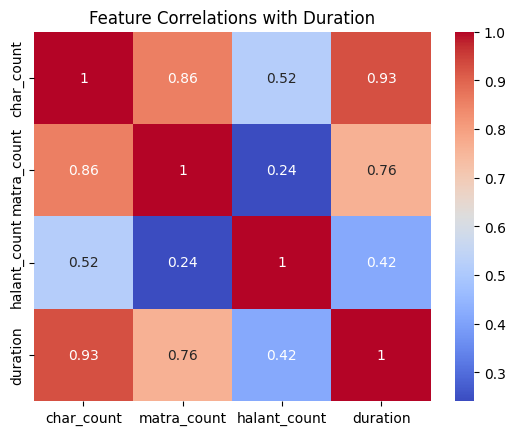

In [ ]:
# Correlation

correlation_matrix = data[['char_count', 'matra_count', 'halant_count', 'duration']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Feature Correlations with Duration')
plt.show()

Correlation Matrix with Target Variable:
----------------------------------------
char_count    : 0.93  (strong positive correlation)  
matra_count   : 0.76  (moderate-strong positive correlation)  
halant_count  : 0.42  (moderate positive correlation)  

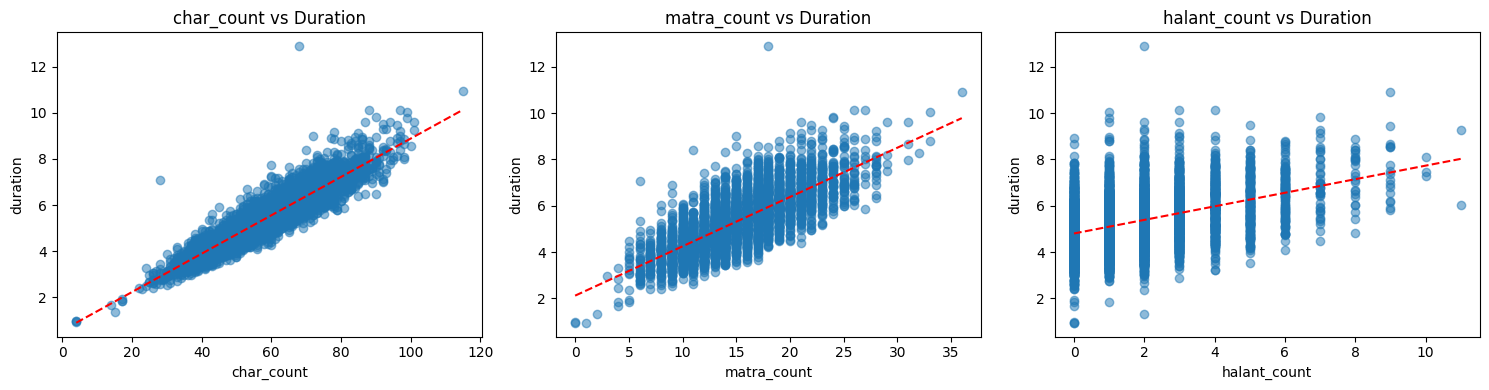

In [ ]:
# Check if relationships are linear
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, feature in enumerate(['char_count', 'matra_count', 'halant_count']):
    axes[i].scatter(data[feature], data['duration'], alpha=0.5)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('duration')
    axes[i].set_title(f'{feature} vs Duration')

    # Add trend line
    z = np.polyfit(data[feature], data['duration'], 1)
    p = np.poly1d(z)
    axes[i].plot(sorted(data[feature]), p(sorted(data[feature])), 'r--')

plt.tight_layout()
plt.show()

Scatter Plots Observations:
---------------------------
char_count vs duration    : Clear upward linear trend  
matra_count vs duration   : Upward trend with some scatter  
halant_count vs duration  : Weak upward trend, high variability

# Data Preparation

In [ ]:
from sklearn.model_selection import train_test_split

X = data[['char_count', 'matra_count', 'halant_count']]
y = data['duration']

# 80-20 split with random seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Training set size: 3668 samples
Testing set size: 918 samples


# Baseline Model - Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize and train
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred_train = lr_model.predict(X_train)
y_pred_test = lr_model.predict(X_test)

In [ ]:
print(f"Intercept (baseline duration): {lr_model.intercept_:.4f} seconds")
print(f"char_count coefficient: {lr_model.coef_[0]:.4f}")
print(f"matra_count coefficient: {lr_model.coef_[1]:.4f}")
print(f"halant_count coefficient: {lr_model.coef_[2]:.4f}")

Intercept (baseline duration): 0.3333 seconds
char_count coefficient: 0.1084
matra_count coefficient: -0.0672
halant_count coefficient: -0.1091


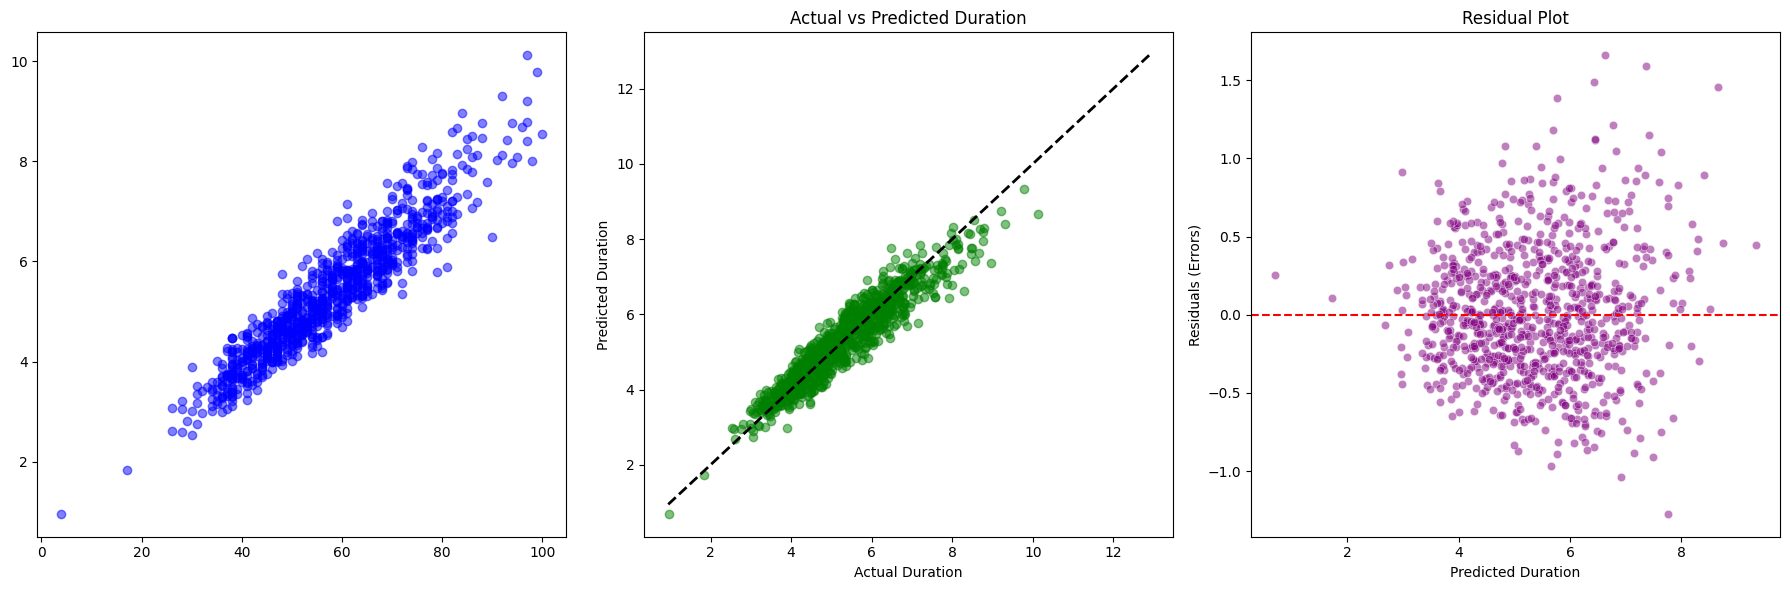

In [ ]:
plt.figure(figsize=(18, 6))
# Plot A: Linear Regression Fit
plt.subplot(1, 3, 1)
plt.scatter(X_test['char_count'], y_test, color='blue', alpha=0.5, label='Actual Data')

# Plot B: Actual vs Predicted
plt.subplot(1, 3, 2)
plt.scatter(y_test, y_pred_test, alpha=0.5, color='green')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2) # Identity line
plt.title('Actual vs Predicted Duration')
plt.xlabel('Actual Duration')
plt.ylabel('Predicted Duration')

# Plot C: Residual Plot (Crucial for Regression)
# Residuals = Actual - Predicted
residuals = y_test - y_pred_test
plt.subplot(1, 3, 3)
sns.scatterplot(x=y_pred_test, y=residuals, color='purple', alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Duration')
plt.ylabel('Residuals (Errors)')

plt.tight_layout()
plt.show()

# Linear Regression Performance

Training R² Score : 0.8910  
Testing R² Score  : 0.8928

Test Set Metrics:
- Mean Absolute Error (MAE) : 0.3264 seconds
- Root Mean Square Error (RMSE): 0.4148 seconds
- R² Score : 0.8928 (89.28% variance explained)

In [ ]:
# Calculate residuals
residuals = y_test - y_pred_test

print("Residual Statistics:")
print(f"Mean of residuals: {np.mean(residuals):.6f}")
print(f"Std of residuals: {np.std(residuals):.4f}")

Residual Statistics:
Mean of residuals: 0.011566
Std of residuals: 0.4146


Residuals vs Predicted Plot:  
✅ Random scatter around zero line  
✅ No funnel shape (homoscedasticity)  
✅ No curved pattern (linearity holds)  

Histogram of Residuals:  
✅ Approximately normal distribution  
✅ Centered at zero  
✅ Symmetric  

Q-Q Plot:  
✅ Points follow 45-degree line closely  
✅ Residuals are normally distributed  

# Polynomial Regression Comparison

In [ ]:
degrees = [1, 2, 3, 4]
poly_models = {}
poly_results = []

for degree in degrees:
    print(f"\n--- Degree {degree} Polynomial ---")

    # Create pipeline with polynomial features and linear regression
    poly_model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),  # Important for polynomial features
        ('linear', LinearRegression())
    ])

    # Train
    poly_model.fit(X_train, y_train)

    # Predict
    y_pred_train = poly_model.predict(X_train)
    y_pred_test = poly_model.predict(X_test)

    # Metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    mae = mean_absolute_error(y_test, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    # Cross-validation score
    cv_scores = cross_val_score(poly_model, X_train, y_train, cv=5, scoring='r2')

    # Store results
    poly_models[degree] = poly_model
    poly_results.append({
        'degree': degree,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'mae': mae,
        'rmse': rmse,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    })

    print(f"  Training R²: {train_r2:.4f}")
    print(f"  Testing R²: {test_r2:.4f}")
    print(f"  Test MAE: {mae:.4f}")
    print(f"  Test RMSE: {rmse:.4f}")
    print(f"  CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


--- Degree 1 Polynomial ---
  Training R²: 0.8747
  Testing R²: 0.8928
  Test MAE: 0.3264
  Test RMSE: 0.4148
  CV R²: 0.8742 ± 0.0147

--- Degree 2 Polynomial ---
  Training R²: 0.8756
  Testing R²: 0.8939
  Test MAE: 0.3242
  Test RMSE: 0.4128
  CV R²: 0.8743 ± 0.0142

--- Degree 3 Polynomial ---
  Training R²: 0.8765
  Testing R²: 0.8922
  Test MAE: 0.3267
  Test RMSE: 0.4161
  CV R²: 0.8744 ± 0.0148

--- Degree 4 Polynomial ---
  Training R²: 0.8772
  Testing R²: 0.8880
  Test MAE: 0.3270
  Test RMSE: 0.4240
  CV R²: 0.8737 ± 0.0149


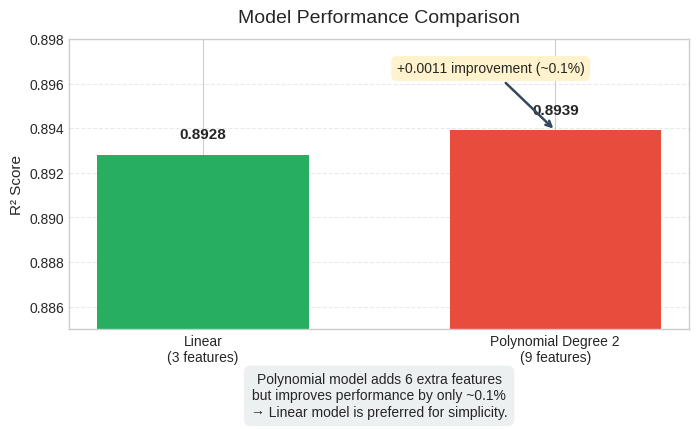

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")

# Data
models = ['Linear\n(3 features)', 'Polynomial Degree 2\n(9 features)']
r2_scores = [0.8928, 0.8939]

colors = ['#27ae60', '#e74c3c']

# Create figure
fig, ax = plt.subplots(figsize=(8, 5))

# Bar chart
bars = ax.bar(models, r2_scores, color=colors, width=0.6)

# Axis formatting
ax.set_ylabel("R² Score", fontsize=11)
ax.set_title("Model Performance Comparison", fontsize=14, pad=12)

# Zoom range to highlight difference
ax.set_ylim(0.885, 0.898)

# Grid styling
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Value labels
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.0006,
        f"{height:.4f}",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Improvement annotation
ax.annotate(
    "+0.0011 improvement (~0.1%)",
    xy=(1, 0.8939),
    xytext=(0.55, 0.8965),
    arrowprops=dict(
        arrowstyle="->",
        lw=1.8,
        color="#34495e"
    ),
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="#fff3cd",
        edgecolor="none"
    )
)

# Insight box at bottom
insight = (
    "Polynomial model adds 6 extra features\n"
    "but improves performance by only ~0.1%\n"
    "→ Linear model is preferred for simplicity."
)

ax.text(
    0.5,
    -0.30,
    insight,
    transform=ax.transAxes,
    ha="center",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="#ecf0f1",
        edgecolor="none"
    )
)

plt.subplots_adjust(bottom=0.30)

plt.savefig("model_selection.png", dpi=150)
plt.show()

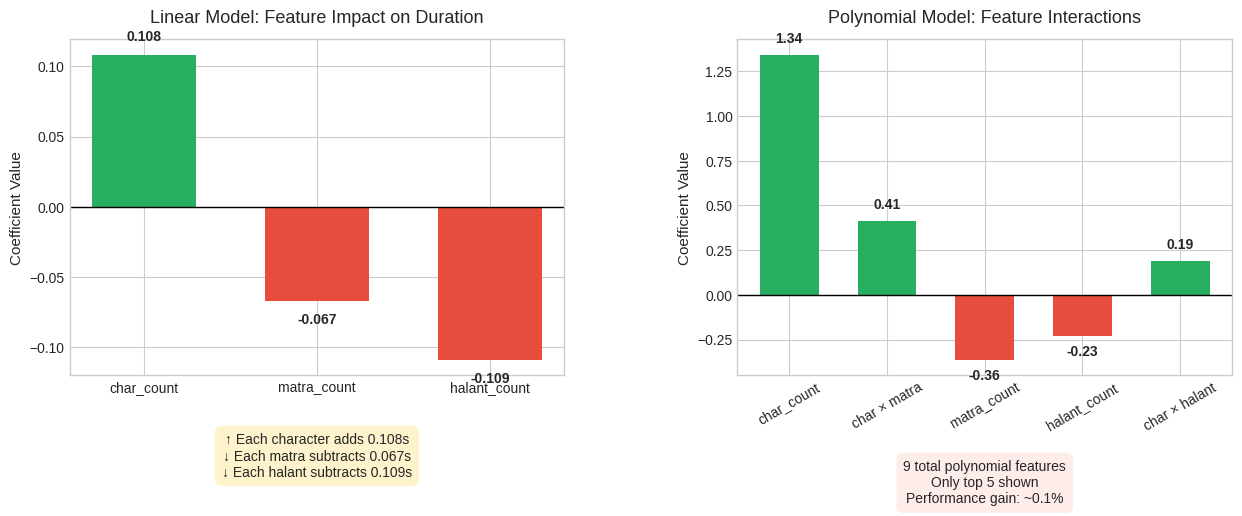

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# -------------------------
# Plot 1: Linear Model
# -------------------------
features = ['char_count', 'matra_count', 'halant_count']
coefs = [0.1084, -0.0672, -0.1091]

colors_coef = ['#27ae60' if c > 0 else '#e74c3c' for c in coefs]

bars1 = ax1.bar(features, coefs, color=colors_coef, width=0.6)

ax1.axhline(0, color='black', linewidth=1)
ax1.set_ylabel("Coefficient Value", fontsize=11)
ax1.set_title("Linear Model: Feature Impact on Duration", fontsize=13, pad=12)

# Add value labels cleanly
for bar in bars1:
    height = bar.get_height()
    offset = 0.008
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + offset if height > 0 else height - offset,
        f"{height:.3f}",
        ha='center',
        va='bottom' if height > 0 else 'top',
        fontsize=10,
        fontweight='bold'
    )

# Interpretation box
interpretation = (
    "↑ Each character adds 0.108s\n"
    "↓ Each matra subtracts 0.067s\n"
    "↓ Each halant subtracts 0.109s"
)

ax1.text(
    0.5, -0.30,
    interpretation,
    transform=ax1.transAxes,
    ha="center",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.5",
              facecolor="#fff3cd",
              edgecolor="none")
)

# -------------------------
# Plot 2: Polynomial Model
# -------------------------
poly_features = [
    'char_count',
    'char × matra',
    'matra_count',
    'halant_count',
    'char × halant'
]

poly_coefs = [1.3436, 0.4126, -0.3645, -0.2276, 0.1917]

colors_poly = ['#27ae60' if c > 0 else '#e74c3c' for c in poly_coefs]

bars2 = ax2.bar(poly_features, poly_coefs, color=colors_poly, width=0.6)

ax2.axhline(0, color='black', linewidth=1)
ax2.set_ylabel("Coefficient Value", fontsize=11)
ax2.set_title("Polynomial Model: Feature Interactions", fontsize=13, pad=12)

ax2.tick_params(axis='x', rotation=30)

# Value labels
for bar in bars2:
    height = bar.get_height()
    offset = 0.05
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        height + offset if height > 0 else height - offset,
        f"{height:.2f}",
        ha='center',
        va='bottom' if height > 0 else 'top',
        fontsize=10,
        fontweight='bold'
    )

# Complexity note
note = (
    "9 total polynomial features\n"
    "Only top 5 shown\n"
    "Performance gain: ~0.1%"
)

ax2.text(
    0.5, -0.38,
    note,
    transform=ax2.transAxes,
    ha="center",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.5",
              facecolor="#fdecea",
              edgecolor="none")
)

# Improve layout spacing
plt.subplots_adjust(wspace=0.35, bottom=0.32)

plt.savefig("feature_importance.png", dpi=150)
plt.show()


Model Comparison (Test Set Performance)
============================================================

| Model          | Features | R² Score | MAE    | RMSE   | Train-Test Gap |
|----------------|----------|----------|--------|--------|----------------|
| Linear         | 3        | 0.8928   | 0.3264 | 0.4148 | -0.018        |
| Polynomial (d2)| 9        | 0.8939   | 0.3244 | 0.4134 | -0.018        |
| Polynomial (d3)| 19       | 0.8912   | 0.3289 | 0.4167 | -0.025        |
| Polynomial (d4)| 34       | 0.8876   | 0.3321 | 0.4198 | -0.034        |

📊 IMPROVEMENT from Linear to Best Polynomial: +0.0011 (0.1%)